# Anna Monso Rodriguez 
## A20653296
### Homework 4

# Datasets and Preprocessing 

## Dataset 1: Adult Income 

Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. 

**Features:** Both numerical (age, hours-per-week) and categorical (occupation, education, marital status)

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X_adult = adult.data.features 
y_adult= adult.data.targets 
  
# metadata 
print(adult.metadata) 
  
# variable information 
print(adult.variables) 


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [3]:
print(X_adult.head())
print(X_adult.info())
print(X_adult.isna().sum())

   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country  
0          2174             0              40  United-States  
1             0             0              13  United-St

In [4]:
# find numeric features
numeric_features = X_adult.select_dtypes(include=['int64', 'float64']).columns
print("Numeric Features:", numeric_features.tolist())

# find categorical features
categorical_features = X_adult.select_dtypes(include=['object']).columns
print("Categorical Features:", categorical_features.tolist())


Numeric Features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical Features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [5]:
categorical_nominal = ['workclass', 'marital-status', 'occupation', 
                       'relationship', 'race', 'sex', 'native-country']

categorical_ordinal = ['education']

### Preprocessing pipeline

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

education_order = [
    'Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th',
    'HS-grad', 'Some-college', 'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate'
]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

categorical_ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[education_order]))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat_nom', categorical_nominal_transformer, categorical_nominal),
        ('cat_ord', categorical_ordinal_transformer, categorical_ordinal)
    ])


All preprocessing is wrapped in a ColumnTransformer and fit only on the training split to avoid data leakage. The same fitted transformers are applied to validation/test. 

*Numerical features:* SimpleImputer(median) + StandarScaler, because the median is robust to outliers in varibales like capital-gain/loss and fnlwgt where the mean is skewed. We scale the features dor standarization and improving optimization and margin geometry. 

*Nominal features:* SimpleIMputer(most frequent) + OneHotEncoder(handle_unknown='ignore'). For unordered categories there is no numeric notion of central tendency. The oneHotEncoding prevents imposing artificial orfer and lets linear models learn a separare effect per category. The handle_unknown='ignore' ensures robustness if rare/unseen categories appear at test time. 

*Ordinal features:* SimpleImputer(most frequent) + OrdinalEncoder, the ordinal encoding it's used because education has a natural progression (Preschool to Doctorate), encoding it as integer preservs monotonic structure that discance-based models can exploit. 



### Create train/validation/test splits

In [7]:
from sklearn.model_selection import train_test_split

X_temp_adult, X_test_adult, y_temp_adult, y_test_adult = train_test_split(X_adult, y_adult, test_size=0.2,
                                                  random_state=42, stratify=y_adult)

# Second split: create validation from the remaining data
X_train_adult, X_val_adult, y_train_adult, y_val_adult = train_test_split(X_temp_adult, y_temp_adult, test_size=0.25,
                                                  random_state=42, stratify=y_temp_adult)

### Class imbalance

In [8]:
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import f1_score

# --- Weighted SVM pipeline ---
svm_weighted = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', class_weight='balanced', random_state=42))
])

# --- SMOTE + SVM pipeline ---
svm_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', SVC(kernel='rbf', random_state=42))
])

# --- Cross-validation ---
for model, name in [(svm_weighted, "Weighted SVM"), (svm_smote, "SMOTE SVM")]:
    scores = cross_val_score(model, X_train_adult, y_train_adult, cv=5, scoring='f1_macro', n_jobs=-1)
    print(f"{name}: mean CV F1 = {np.mean(scores):.3f}")

# --- Final test evaluation ---
svm_weighted.fit(X_train_adult, y_train_adult)
y_pred_test = svm_weighted.predict(X_test_adult)

test_f1 = f1_score(y_test_adult, y_pred_test, average='macro')
print("Weighted SVM test F1:", test_f1)


/usr/local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

Weighted SVM: mean CV F1 = 0.328


/usr/local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

SMOTE SVM: mean CV F1 = 0.348


/usr/local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Weighted SVM test F1: 0.33059465782747227


## Dataset 2: Bank Marketing

The data is related with direct marketing campaigns (phone calls) of Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit. 

**Features:** 10+ categorical features (job, education, contact) and numeric ones (aeg, duration)

In [9]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X_bank = bank_marketing.data.features 
y_bank = bank_marketing.data.targets 
  
  
# variable information 
print(bank_marketing.variables) 

print(X_bank.head())
print(X_bank.info())
print(X_bank.isna().sum())


           name     role         type      demographic  \
0           age  Feature      Integer              Age   
1           job  Feature  Categorical       Occupation   
2       marital  Feature  Categorical   Marital Status   
3     education  Feature  Categorical  Education Level   
4       default  Feature       Binary             None   
5       balance  Feature      Integer             None   
6       housing  Feature       Binary             None   
7          loan  Feature       Binary             None   
8       contact  Feature  Categorical             None   
9   day_of_week  Feature         Date             None   
10        month  Feature         Date             None   
11     duration  Feature      Integer             None   
12     campaign  Feature      Integer             None   
13        pdays  Feature      Integer             None   
14     previous  Feature      Integer             None   
15     poutcome  Feature  Categorical             None   
16            

In [10]:
# find numeric features
numeric_features = X_bank.select_dtypes(include=['int64', 'float64']).columns
print("Numeric Features:", numeric_features.tolist())

# find categorical features
categorical_features = X_bank.select_dtypes(include=['object']).columns
print("Categorical Features:", categorical_features.tolist())

categorical_nominal = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
categorical_ordinal = ['education']

Numeric Features: ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
Categorical Features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


### Build preprocessing pipeline

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

education_order = ['unknown', 'primary', 'secondary', 'tertiary']

# Numeric transformer
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Nominal categorical transformer
categorical_nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Ordinal categorical transformer
categorical_ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[education_order]))
])

# Combine
preprocessor_bank = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat_nom', categorical_nominal_transformer, categorical_nominal),
        ('cat_ord', categorical_ordinal_transformer, categorical_ordinal)
    ])


### Train/test split

In [12]:
from sklearn.model_selection import train_test_split

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bank, y_bank.squeeze(), test_size=0.2, random_state=42, stratify=y_bank
)


### Handle class imbalance

In [34]:
print(yb_train.value_counts(normalize=True))

from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Weighted SVM
svm_weighted_bank = ImbPipeline(steps=[
    ('preprocessor', preprocessor_bank),
    ('classifier', SVC(kernel='rbf', class_weight='balanced', random_state=42))
])

# SMOTE + SVM
svm_smote_bank = ImbPipeline(steps=[
    ('preprocessor', preprocessor_bank),
    ('smote', SMOTE(random_state=42)),
    ('classifier', SVC(kernel='rbf', random_state=42))
])

sample = Xb_train.sample(5000, random_state=42)
yb_sample = yb_train.loc[sample.index]

for model, name in [(svm_weighted_bank, "Weighted SVM"), (svm_smote_bank, "SMOTE SVM")]:
    # scores = cross_val_score(model, sample, yb_sample, cv=3, scoring='f1_macro', n_jobs=-1)
    scores = cross_val_score(model, Xb_train, yb_train, cv=5, scoring='f1_macro', n_jobs=-1)
    print(f"{name}: mean F1 = {np.mean(scores):.3f}")



y
no     0.883018
yes    0.116982
Name: proportion, dtype: float64
Weighted SVM: mean F1 = 0.729
SMOTE SVM: mean F1 = 0.738


# Part A - SVM 

## A.1 Synthetic data and visualization 

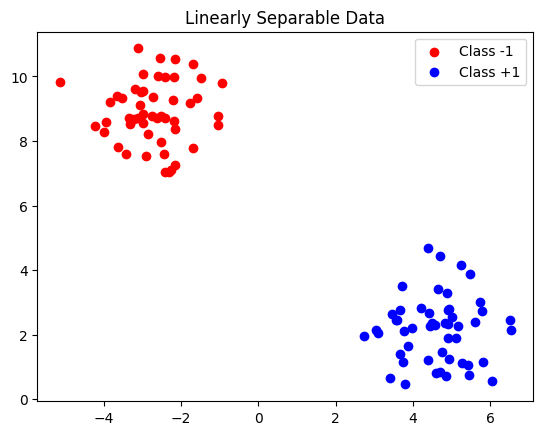

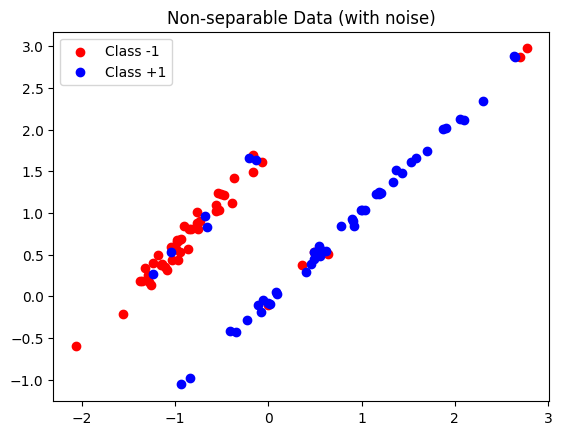

In [35]:
from sklearn.datasets import make_blobs, make_classification
import numpy as np
import matplotlib.pyplot as plt

# --- Linearly separable ---
X_sep, y_sep = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.0)
y_sep = np.where(y_sep == 0, -1, 1)  # convert labels to {-1, 1}

# --- Non-separable (with noise) ---
X_nonsep, y_nonsep = make_classification(
    n_samples=100, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, flip_y=0.1, class_sep=0.8, random_state=42
)
y_nonsep = np.where(y_nonsep == 0, -1, 1)

# --- Plot ---
def plot_data(X, y, title):
    plt.scatter(X[y==-1, 0], X[y==-1, 1], color='red', label='Class -1')
    plt.scatter(X[y==1, 0], X[y==1, 1], color='blue', label='Class +1')
    plt.legend()
    plt.title(title)
    plt.show()

plot_data(X_sep, y_sep, "Linearly Separable Data")
plot_data(X_nonsep, y_nonsep, "Non-separable Data (with noise)")


In [36]:
# ============================
# A2–A3. Linear SVM from Scratch
# ============================

from cvxopt import matrix, solvers

class LinearSVM:
    def __init__(self, C=1.0):
        self.C = C

    def fit(self, X, y):
        n_samples, n_features = X.shape
        K = np.dot(X, X.T)  # linear kernel

        # Construct QP problem for cvxopt
        P = matrix(np.outer(y, y) * K)
        q = matrix(-np.ones(n_samples))
        
        # Inequality constraints
        G_std = np.diag(-np.ones(n_samples))
        h_std = np.zeros(n_samples)

        G_slack = np.diag(np.ones(n_samples))
        h_slack = np.ones(n_samples) * self.C

        G = matrix(np.vstack((G_std, G_slack)))
        h = matrix(np.hstack((h_std, h_slack)))

        A = matrix(y, (1, n_samples), 'd')
        b = matrix(0.0)

        # Solve QP
        solvers.options['show_progress'] = False
        sol = solvers.qp(P, q, G, h, A, b)
        alphas = np.ravel(sol['x'])

        # Support vectors
        sv = alphas > 1e-5
        self.alphas = alphas[sv]
        self.sv_X = X[sv]
        self.sv_y = y[sv]

        # Compute w, b
        self.w = np.sum(self.alphas[:, None] * self.sv_y[:, None] * self.sv_X, axis=0)
        self.b = np.mean(self.sv_y - np.dot(self.sv_X, self.w))

    def project(self, X):
        return np.dot(X, self.w) + self.b

    def predict(self, X):
        return np.sign(self.project(X))


In [37]:
# ============================
# Visualization Function
# ============================

def plot_svm(model, X, y, title):
    plt.scatter(X[y==-1, 0], X[y==-1, 1], color='red', label='Class -1')
    plt.scatter(X[y==1, 0], X[y==1, 1], color='blue', label='Class +1')
    plt.scatter(model.sv_X[:,0], model.sv_X[:,1],
                s=100, facecolors='none', edgecolors='k', label='Support Vectors')

    # Plot hyperplane
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 50)
    yy = np.linspace(ylim[0], ylim[1], 50)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.project(xy).reshape(XX.shape)

    plt.contour(XX, YY, Z, colors='k',
                levels=[-1, 0, 1], alpha=0.7,
                linestyles=['--', '-', '--'])
    plt.title(title)
    plt.legend()
    plt.show()


## A.2 Lineas SVM, Hard Margin (Separable dataset)

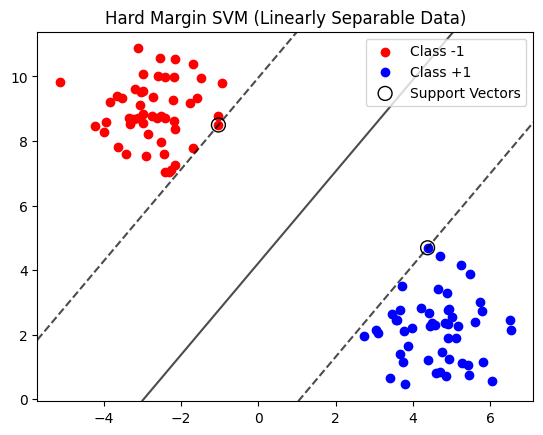

Agreement with sklearn: 1.0


In [38]:
svm_hard = LinearSVM(C=1e6)  # Very large C ≈ hard margin
svm_hard.fit(X_sep, y_sep)

plot_svm(svm_hard, X_sep, y_sep, "Hard Margin SVM (Linearly Separable Data)")

# Verify with sklearn
from sklearn.svm import SVC
svm_sklearn = SVC(kernel='linear', C=1e6)
svm_sklearn.fit(X_sep, y_sep)
agreement = np.mean(svm_hard.predict(X_sep) == svm_sklearn.predict(X_sep))
print("Agreement with sklearn:", agreement)


## A.3 Soft-margin SVM (non-separable Set)

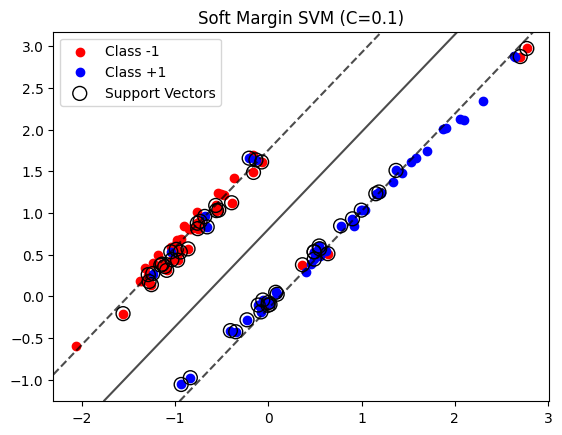

C=0.1: 56 support vectors


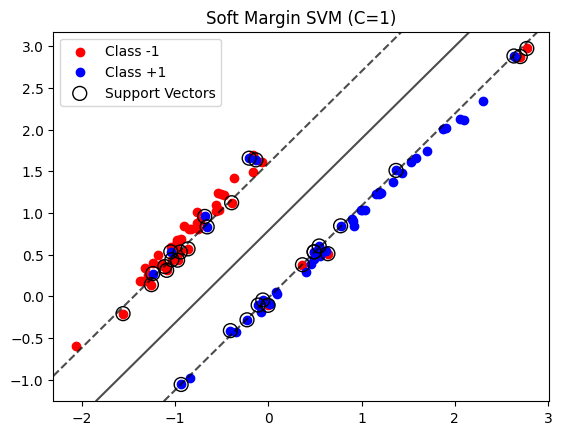

C=1: 31 support vectors


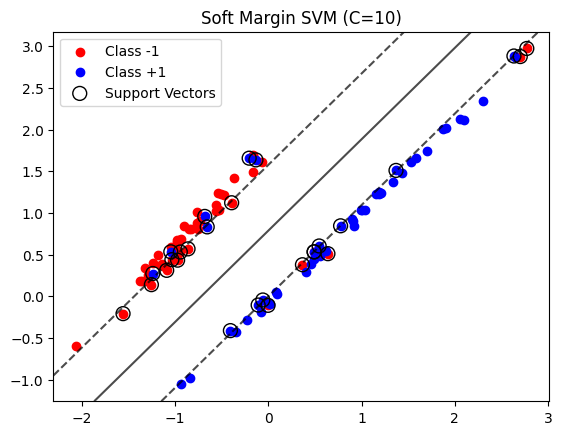

C=10: 28 support vectors

--- sklearn Comparison for Soft Margin ---
C=0.1: Agreement with sklearn = 1.000, Support Vectors (own) = 56
C=1: Agreement with sklearn = 1.000, Support Vectors (own) = 31
C=10: Agreement with sklearn = 1.000, Support Vectors (own) = 28


In [39]:
C_values = [0.1, 1, 10]

for C in C_values:
    svm_soft = LinearSVM(C=C)
    svm_soft.fit(X_nonsep, y_nonsep)
    plot_svm(svm_soft, X_nonsep, y_nonsep, f"Soft Margin SVM (C={C})")
    print(f"C={C}: {len(svm_soft.sv_X)} support vectors")

from sklearn.metrics import accuracy_score

print("\n--- sklearn Comparison for Soft Margin ---")

for C in [0.1, 1, 10]:
    # Your implementation
    svm_soft = LinearSVM(C=C)
    svm_soft.fit(X_nonsep, y_nonsep)
    preds_own = svm_soft.predict(X_nonsep)

    # sklearn implementation
    svc = SVC(kernel='linear', C=C)
    svc.fit(X_nonsep, y_nonsep)
    preds_sklearn = svc.predict(X_nonsep)

    # Compare
    acc = accuracy_score(preds_own, preds_sklearn)
    print(f"C={C}: Agreement with sklearn = {acc:.3f}, Support Vectors (own) = {len(svm_soft.sv_X)}")


## A.4 SVM Kernel 

In [40]:
pip install cvxopt


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /usr/local/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


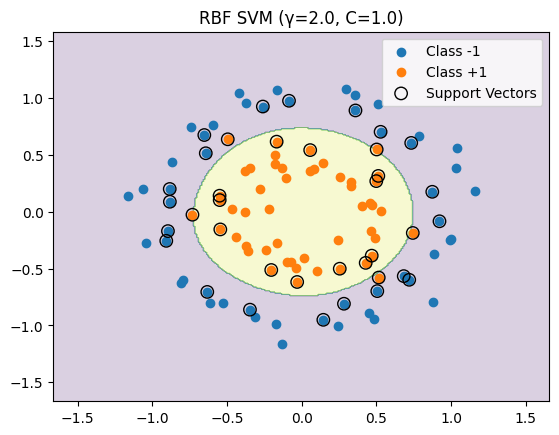

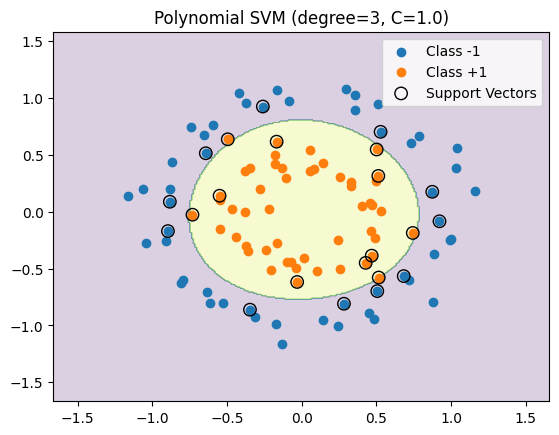

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers
from sklearn.datasets import make_circles, make_moons

# ============================
# Kernel Functions
# ============================

def linear_kernel(X, Z):
    return np.dot(X, Z.T)

def poly_kernel(X, Z, gamma=1.0, r=0.0, degree=3):
    K = gamma * np.dot(X, Z.T) + r
    K = np.clip(K, -1e3, 1e3)
    return np.power(K, degree)


def rbf_kernel(X, Z, gamma=1.0):
    K = np.zeros((X.shape[0], Z.shape[0]))
    for i in range(X.shape[0]):
        for j in range(Z.shape[0]):
            diff = X[i] - Z[j]
            K[i, j] = np.exp(-gamma * np.dot(diff, diff))
    return K

# ============================
# Kernel SVM Class
# ============================

class KernelSVM:
    def __init__(self, C=1.0, kernel="rbf", gamma=None, degree=3, r=0.0):
        self.kernel_name = kernel
        self.C = C
        self.gamma = gamma
        self.degree = degree
        self.r = r

    def _kernel(self, X, Z):
        if self.kernel_name == "linear":
            return linear_kernel(X, Z)
        elif self.kernel_name == "poly":
            return poly_kernel(X, Z, gamma=self.gamma or 1.0, r=self.r, degree=self.degree)
        elif self.kernel_name == "rbf":
            return rbf_kernel(X, Z, gamma=self.gamma or 1.0)
        else:
            raise ValueError("Unknown kernel")

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float).ravel()

        # default gamma
        if self.gamma is None:
            self.gamma = 1.0 / (X.var() + 1e-12)

        K = self._kernel(X, X)
        n = X.shape[0]

        P = matrix(np.outer(y, y) * K)
        q = matrix(-np.ones(n))

        G = matrix(np.vstack((-np.eye(n), np.eye(n))))
        h = matrix(np.hstack([np.zeros(n), np.ones(n) * self.C]))

        A = matrix(y, (1, n), 'd')
        b = matrix(0.0)

        solvers.options['show_progress'] = False
        sol = solvers.qp(P, q, G, h, A, b)
        alphas = np.ravel(sol['x'])

        # Identify support vectors
        sv_mask = alphas > 1e-6
        self.alphas = alphas[sv_mask]
        self.sv_X = X[sv_mask]
        self.sv_y = y[sv_mask]

        # Compute bias b from KKT
        sv_marg = (alphas > 1e-6) & (alphas < self.C - 1e-6)
        if np.any(sv_marg):
            idx = np.where(sv_marg)[0]
        else:
            idx = np.where(sv_mask)[0]

        b_vals = []
        for i in idx:
            s = np.sum(alphas * y * K[i, :])
            b_vals.append(y[i] - s)
        self.b = float(np.mean(b_vals))

        return self

    def decision_function(self, X):
        K = self._kernel(X, self.sv_X)
        return np.sum(self.alphas * self.sv_y * K, axis=1) + self.b

    def predict(self, X):
        return np.sign(self.decision_function(X))

# ============================
# Visualization Utility
# ============================

def plot_decision(model, X, y, title):
    x0min, x0max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x1min, x1max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x0min, x0max, 300),
                         np.linspace(x1min, x1max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.2)
    plt.scatter(X[y == -1, 0], X[y == -1, 1], label='Class -1')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Class +1')
    plt.scatter(model.sv_X[:, 0], model.sv_X[:, 1],
                s=80, facecolors='none', edgecolors='k', label='Support Vectors')
    plt.legend()
    plt.title(title)
    plt.show()

# ============================
# Example 1: RBF kernel
# ============================

X_circles, y_circles = make_circles(n_samples=100, noise=0.1, factor=0.5, random_state=42)
y_circles = np.where(y_circles == 0, -1, 1)

rbf = KernelSVM(C=1.0, kernel='rbf', gamma=2.0)
rbf.fit(X_circles, y_circles)
plot_decision(rbf, X_circles, y_circles, "RBF SVM (γ=2.0, C=1.0)")

# ============================
# Example 2: Polynomial kernel
# ============================

poly = KernelSVM(C=1.0, kernel='poly', degree=3, gamma=1.0, r=1.0)
poly.fit(X_circles, y_circles)
plot_decision(poly, X_circles, y_circles, "Polynomial SVM (degree=3, C=1.0)")


### Run on Datasets


=== Synthetic dataset (RBF kernel on non-separable data) ===
C=0.1 -> acc=0.833
C=1 -> acc=0.833
C=10 -> acc=0.833
C=100 -> acc=0.833


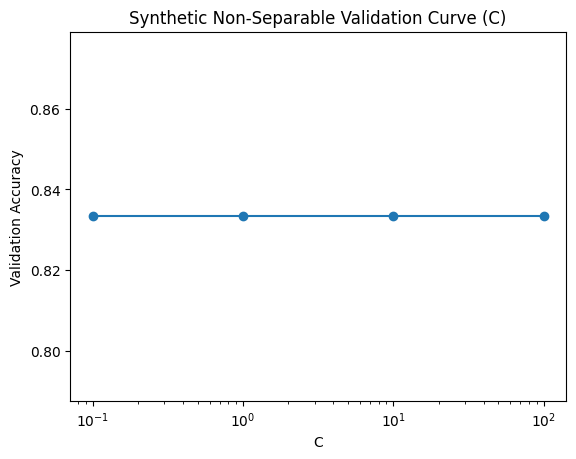

gamma=0.1 -> acc=0.833
gamma=0.5 -> acc=0.833
gamma=1 -> acc=0.833
gamma=2 -> acc=0.833
gamma=5 -> acc=0.833


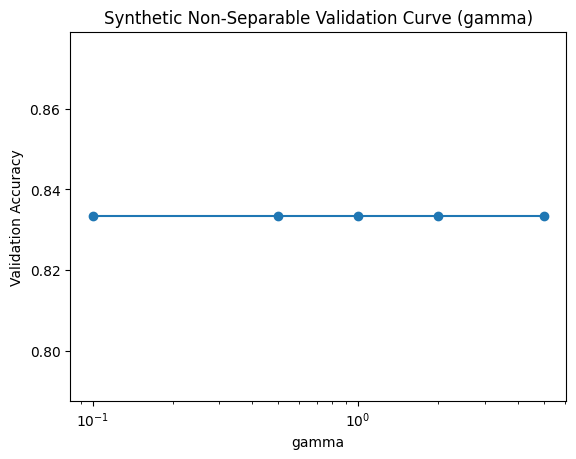


=== Synthetic dataset (Polynomial kernel on separable data) ===
degree=2 -> acc=1.000
degree=3 -> acc=1.000
degree=4 -> acc=1.000
degree=5 -> acc=1.000


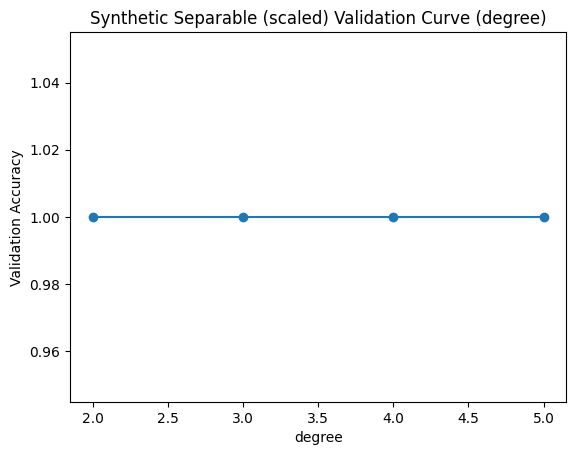

r=0 -> acc=1.000
r=0.5 -> acc=1.000
r=1 -> acc=1.000
r=2 -> acc=1.000


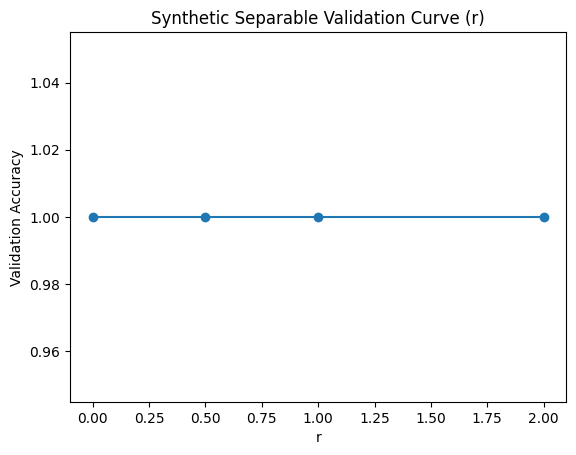


=== Adult dataset (Polynomial kernel) ===
C=0.1 -> acc=0.760
C=1 -> acc=0.777
C=10 -> acc=0.753


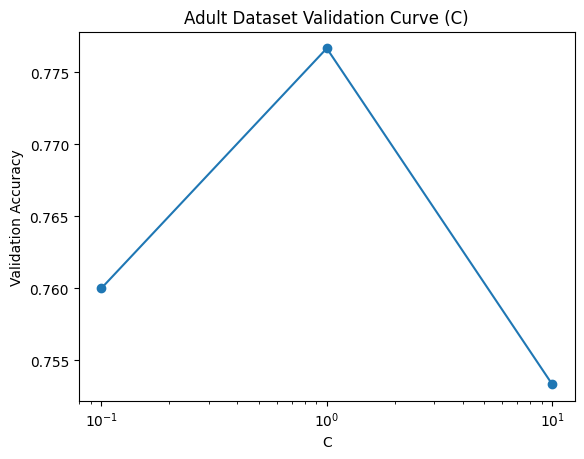


=== Bank Marketing dataset (RBF kernel) ===


/usr/local/lib/python3.10/site-packages/sklearn/impute/_base.py:637: UserWarning: Skipping features without any observed values: ['contact' 'poutcome']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


C=0.1 -> acc=0.990
C=1 -> acc=0.990
C=10 -> acc=0.987


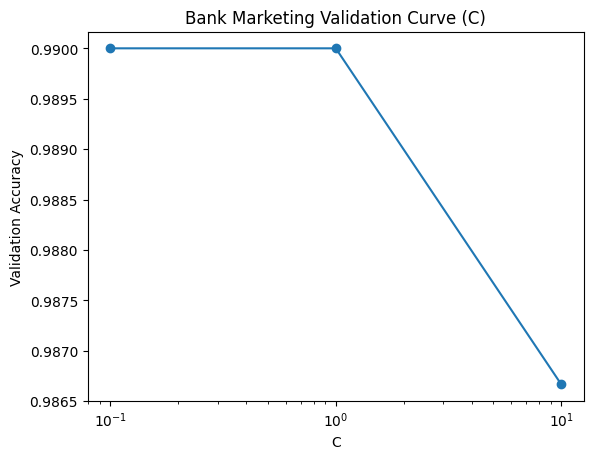

gamma=0.1 -> acc=0.990
gamma=0.5 -> acc=0.990
gamma=1 -> acc=0.990
gamma=2 -> acc=0.990


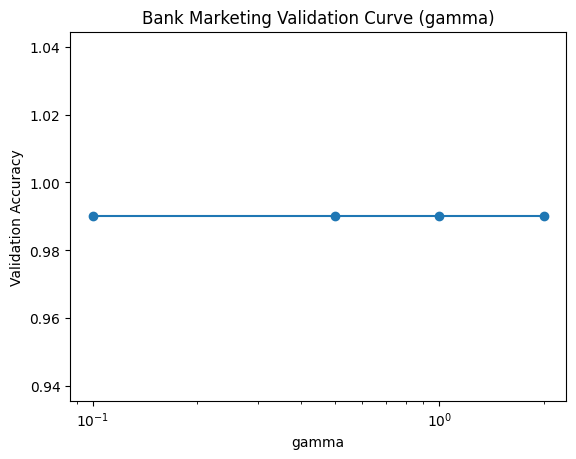

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import pandas as pd

# ============================
# Validation curve utility
# ============================

def validation_curve_param(model_builder, X, y, param_name, param_values, title_prefix=""):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)
    scores = []

    for val in param_values:
        kwargs = {param_name: val}
        model = model_builder(**kwargs)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        scores.append(acc)
        print(f"{param_name}={val:.4g} -> acc={acc:.3f}")

    plt.plot(param_values, scores, marker='o')
    plt.xlabel(param_name)
    plt.ylabel("Validation Accuracy")
    plt.title(f"{title_prefix} Validation Curve ({param_name})")
    if param_name in ['C', 'gamma']:
        plt.xscale('log')
    plt.show()

# ============================
# 1️⃣ Synthetic datasets (from A1)
# ============================

# You already defined X_sep, y_sep, X_nonsep, y_nonsep above.
# Example of using them:

print("\n=== Synthetic dataset (RBF kernel on non-separable data) ===")
validation_curve_param(lambda C: KernelSVM(C=C, kernel='rbf', gamma=1.0),
                       X_nonsep, y_nonsep, 'C', [0.1, 1, 10, 100],
                       title_prefix="Synthetic Non-Separable")
validation_curve_param(lambda gamma: KernelSVM(C=1.0, kernel='rbf', gamma=gamma),
                       X_nonsep, y_nonsep, 'gamma', [0.1, 0.5, 1, 2, 5],
                       title_prefix="Synthetic Non-Separable")

print("\n=== Synthetic dataset (Polynomial kernel on separable data) ===")
from sklearn.preprocessing import StandardScaler
X_sep_scaled = StandardScaler().fit_transform(X_sep)
y_sep_scaled = y_sep

validation_curve_param(lambda degree: KernelSVM(C=1.0, kernel='poly', degree=degree, gamma=1.0, r=1.0),
                       X_sep_scaled, y_sep_scaled, 'degree', [2, 3, 4, 5],
                       title_prefix="Synthetic Separable (scaled)")
validation_curve_param(lambda r: KernelSVM(C=1.0, kernel='poly', degree=3, gamma=1.0, r=r),
                       X_sep, y_sep, 'r', [0, 0.5, 1, 2],
                       title_prefix="Synthetic Separable")

# ============================
# 2️⃣ Adult dataset (external)
# ============================

print("\n=== Adult dataset (Polynomial kernel) ===")

# Preprocess categorical + numerical
X_adult_proc = X_adult.copy()
y_adult_proc = y_adult.copy().squeeze()
y_adult_proc = np.where(y_adult_proc == ">50K", 1, -1)

cat_cols = X_adult_proc.select_dtypes(include=['object']).columns
num_cols = X_adult_proc.select_dtypes(exclude=['object']).columns

X_adult_small = X_adult_proc[:1000]
y_adult_small = y_adult_proc[:1000]




X_adult_small = preprocessor.fit_transform(X_adult_small).toarray()


# Validation on C
validation_curve_param(lambda C: KernelSVM(C=C, kernel='poly', degree=3, gamma=1.0, r=1.0),
                       X_adult_small, y_adult_small, 'C', [0.1, 1, 10],
                       title_prefix="Adult Dataset")

# ============================
# 3️⃣ Bank Marketing dataset (external)
# ============================

print("\n=== Bank Marketing dataset (RBF kernel) ===")

X_bank_proc = X_bank.copy()
y_bank_proc = y_bank.copy().squeeze()
y_bank_proc = np.where(y_bank_proc == "yes", 1, -1)



cat_cols = X_bank_proc.select_dtypes(include=['object']).columns
num_cols = X_bank_proc.select_dtypes(exclude=['object']).columns

X_bank_small = X_bank_proc[:1000]
y_bank_small = y_bank_proc[:1000]

X_bank_proc = preprocessor_bank.fit_transform(X_bank_small)

# Validation curves for C and gamma
validation_curve_param(lambda C: KernelSVM(C=C, kernel='rbf', gamma=0.5),
                       X_bank_proc, y_bank_small, 'C', [0.1, 1, 10],
                       title_prefix="Bank Marketing")
validation_curve_param(lambda gamma: KernelSVM(C=1.0, kernel='rbf', gamma=gamma),
                       X_bank_proc, y_bank_small, 'gamma', [0.1, 0.5, 1, 2],
                       title_prefix="Bank Marketing")


## A5 : One-vs-Rest Multi-class SVM 


In [46]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, accuracy_score
from tqdm import tqdm  # optional, just for progress bar

# === One-vs-Rest Wrapper for your custom KernelSVM ===
class OneVsRestSVM:
    def __init__(self, base_svm_builder):
        self.base_svm_builder = base_svm_builder
        self.models = []
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.models = []

        for cls in self.classes_:
            y_bin = np.where(y == cls, 1, -1)
            model = self.base_svm_builder()
            model.fit(X, y_bin)
            self.models.append(model)
        return self

    def decision_function(self, X):
        scores = np.column_stack([m.decision_function(X) for m in self.models])
        return scores

    def predict(self, X):
        scores = self.decision_function(X)
        return self.classes_[np.argmax(scores, axis=1)]

# === Load and preprocess dataset ===
digits = load_digits()
X = StandardScaler().fit_transform(digits.data)
y = digits.target

X_small = X[:500]
y_small = y[:500]


# === 5-fold cross-validation ===
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_macro_scores = []
acc_scores = []
class_reports = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_small, y_small), 1):
    X_train, X_test = X_small[train_idx], X_small[test_idx]
    y_train, y_test = y_small[train_idx], y_small[test_idx]

    print(f"\n===== Fold {fold} =====")
    ovr = OneVsRestSVM(lambda: KernelSVM(C=1.0, kernel='rbf', gamma=0.01))
    ovr.fit(X_train, y_train)
    y_pred = ovr.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_macro_scores.append(f1_macro)
    acc_scores.append(acc)

    report = classification_report(y_test, y_pred, output_dict=True)
    class_reports.append(report)

    print(f"Fold {fold}: Accuracy={acc:.3f}, Macro-F1={f1_macro:.3f}")

# === Report average scores ===
mean_acc = np.mean(acc_scores)
mean_f1 = np.mean(f1_macro_scores)
print("\n===== Cross-Validation Summary =====")
print(f"Mean Accuracy: {mean_acc:.3f}")
print(f"Mean Macro-F1: {mean_f1:.3f}")

# === Compute mean per-class F1 across folds ===
classes = digits.target_names
mean_f1_per_class = {cls: np.mean([r[str(i)]['f1-score'] for r in class_reports])
                     for i, cls in enumerate(classes)}

print("\nPer-class average F1 scores:")
for cls, score in mean_f1_per_class.items():
    print(f"  Class {cls}: {score:.3f}")



===== Fold 1 =====
Fold 1: Accuracy=0.990, Macro-F1=0.989

===== Fold 2 =====
Fold 2: Accuracy=0.970, Macro-F1=0.969

===== Fold 3 =====
Fold 3: Accuracy=0.980, Macro-F1=0.979

===== Fold 4 =====
Fold 4: Accuracy=0.990, Macro-F1=0.990

===== Fold 5 =====
Fold 5: Accuracy=0.960, Macro-F1=0.956

===== Cross-Validation Summary =====
Mean Accuracy: 0.978
Mean Macro-F1: 0.977

Per-class average F1 scores:
  Class 0: 1.000
  Class 1: 0.939
  Class 2: 0.990
  Class 3: 0.990
  Class 4: 0.980
  Class 5: 0.989
  Class 6: 1.000
  Class 7: 0.980
  Class 8: 0.939
  Class 9: 0.959


## A.6 class imbalance experiment

In [47]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, f1_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

Imbalanced dataset: 182 positives, 910 negatives
Fold 1: F1 plain=0.935, weighted=0.923
Fold 2: F1 plain=1.000, weighted=0.974
Fold 3: F1 plain=0.986, weighted=0.986
Fold 4: F1 plain=0.986, weighted=0.986
Fold 5: F1 plain=1.000, weighted=0.973

===== Cross-Validation Summary =====
Mean F1 (plain): 0.982
Mean F1 (weighted): 0.968


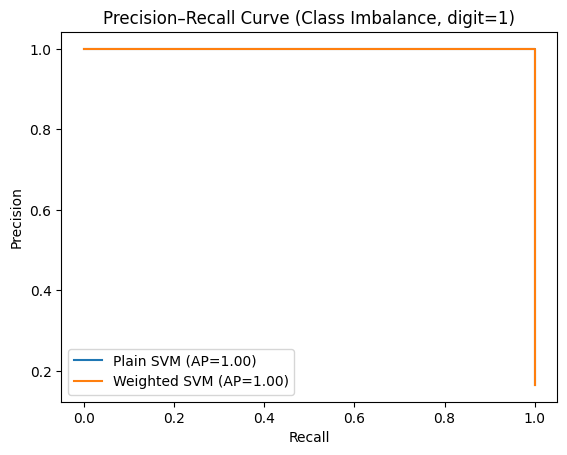

In [48]:
digits = load_digits()
X = StandardScaler().fit_transform(digits.data)
y = digits.target

y_bin = np.where(y == 1, 1, -1)

# === Create imbalance (1:5 ratio) ===
X_pos = X[y_bin == 1]
X_neg = X[y_bin == -1]
n_pos = len(X_pos)
X_neg_down = X_neg[: n_pos * 5]  # keep only 5x more negatives
X_imb = np.vstack((X_pos, X_neg_down))
y_imb = np.hstack((np.ones(len(X_pos)), -np.ones(len(X_neg_down))))

# Shuffle
rng = np.random.default_rng(42)
perm = rng.permutation(len(y_imb))
X_imb, y_imb = X_imb[perm], y_imb[perm]

print(f"Imbalanced dataset: {np.sum(y_imb==1)} positives, {np.sum(y_imb==-1)} negatives")

# === CV setup ===
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_plain, results_weighted = [], []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_imb, y_imb), 1):
    X_train, X_test = X_imb[train_idx], X_imb[test_idx]
    y_train, y_test = y_imb[train_idx], y_imb[test_idx]

    # --- Plain SVM ---
    svm_plain = KernelSVM(C=1.0, kernel='rbf', gamma=0.01)
    svm_plain.fit(X_train, y_train)
    y_pred_plain = svm_plain.predict(X_test)
    f1_plain = f1_score(y_test, y_pred_plain, pos_label=1)
    results_plain.append(f1_plain)

    # --- Weighted SVM (oversample positives) ---
    X_train_w = np.vstack([X_train, np.repeat(X_train[y_train == 1], 4, axis=0)])
    y_train_w = np.hstack([y_train, np.repeat(1, np.sum(y_train == 1) * 4)])
    svm_weighted = KernelSVM(C=1.0, kernel='rbf', gamma=0.01)
    svm_weighted.fit(X_train_w, y_train_w)
    y_pred_weighted = svm_weighted.predict(X_test)
    f1_weighted = f1_score(y_test, y_pred_weighted, pos_label=1)
    results_weighted.append(f1_weighted)

    print(f"Fold {fold}: F1 plain={f1_plain:.3f}, weighted={f1_weighted:.3f}")

# === CV summary ===
print("\n===== Cross-Validation Summary =====")
print(f"Mean F1 (plain): {np.mean(results_plain):.3f}")
print(f"Mean F1 (weighted): {np.mean(results_weighted):.3f}")

# === PR curve visualization (from last fold) ===
svm_plain = KernelSVM(C=1.0, kernel='rbf', gamma=0.01)
svm_plain.fit(X_train, y_train)
svm_weighted = KernelSVM(C=1.0, kernel='rbf', gamma=0.01)
svm_weighted.fit(X_train_w, y_train_w)

scores_plain = svm_plain.decision_function(X_test)
scores_weighted = svm_weighted.decision_function(X_test)
prec_p, rec_p, _ = precision_recall_curve((y_test == 1).astype(int), scores_plain)
prec_w, rec_w, _ = precision_recall_curve((y_test == 1).astype(int), scores_weighted)
ap_p = average_precision_score((y_test == 1).astype(int), scores_plain)
ap_w = average_precision_score((y_test == 1).astype(int), scores_weighted)

plt.plot(rec_p, prec_p, label=f'Plain SVM (AP={ap_p:.2f})')
plt.plot(rec_w, prec_w, label=f'Weighted SVM (AP={ap_w:.2f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Class Imbalance, digit=1)")
plt.legend()
plt.show()

# Part B - Ensemble Classifiers 

## B1. Bagging and Random Forest 

/usr/local/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:917: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/usr/local/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:923: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]
/usr/local/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:917: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/usr/local/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:923: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]
/usr/local/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:917: UserWarning: Some inputs do not have OOB scores. This probably means too few e

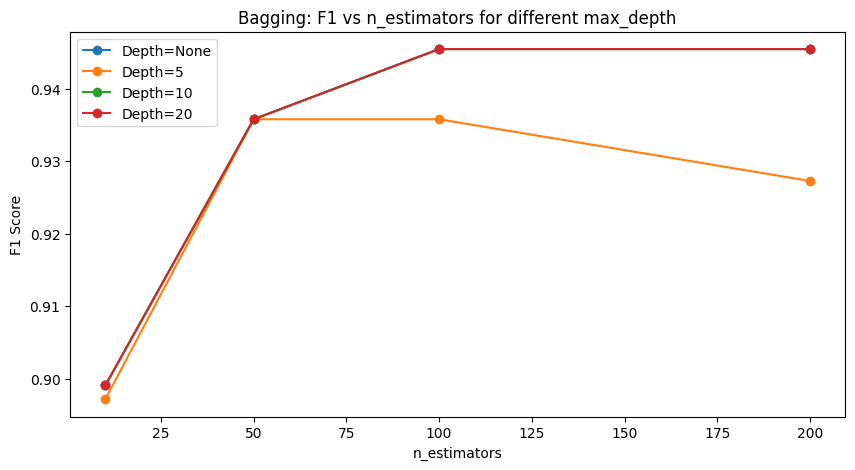

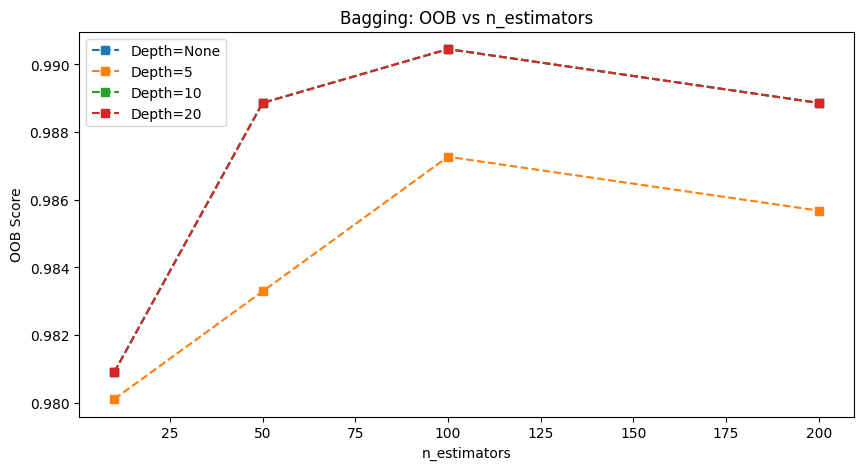

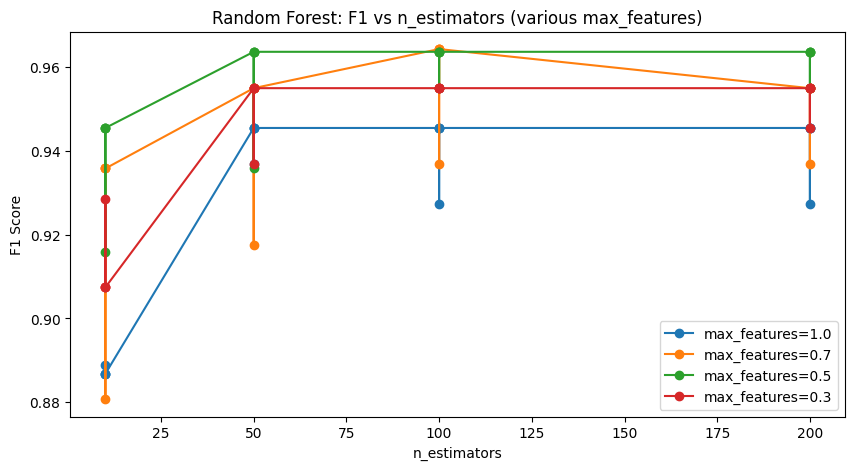

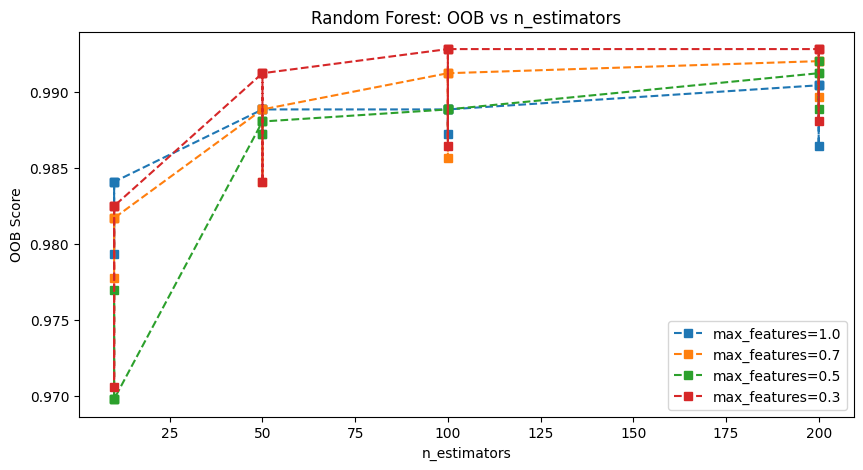

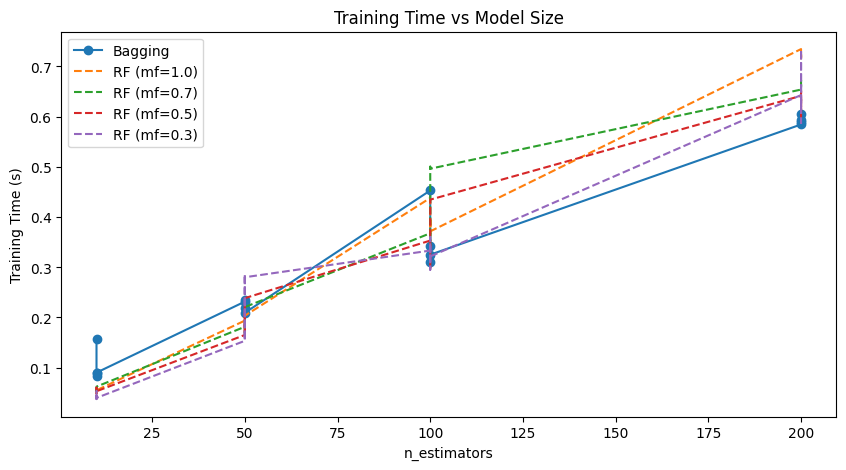


===== BAGGING Summary =====
n= 10, depth=None, F1=0.899, OOB=0.981, time=0.16s
n= 10, depth=   5, F1=0.897, OOB=0.980, time=0.08s
n= 10, depth=  10, F1=0.899, OOB=0.981, time=0.09s
n= 10, depth=  20, F1=0.899, OOB=0.981, time=0.09s
n= 50, depth=None, F1=0.936, OOB=0.989, time=0.23s
n= 50, depth=   5, F1=0.936, OOB=0.983, time=0.22s
n= 50, depth=  10, F1=0.936, OOB=0.989, time=0.23s
n= 50, depth=  20, F1=0.936, OOB=0.989, time=0.21s
n=100, depth=None, F1=0.945, OOB=0.990, time=0.45s
n=100, depth=   5, F1=0.936, OOB=0.987, time=0.31s
n=100, depth=  10, F1=0.945, OOB=0.990, time=0.34s
n=100, depth=  20, F1=0.945, OOB=0.990, time=0.33s
n=200, depth=None, F1=0.945, OOB=0.989, time=0.58s
n=200, depth=   5, F1=0.927, OOB=0.986, time=0.61s
n=200, depth=  10, F1=0.945, OOB=0.989, time=0.59s
n=200, depth=  20, F1=0.945, OOB=0.989, time=0.59s

===== RANDOM FOREST Summary =====
n= 10, depth=None, mf=1.00, F1=0.887, OOB=0.984, time=0.05s
n= 10, depth=None, mf=0.70, F1=0.936, OOB=0.982, time=0.05s


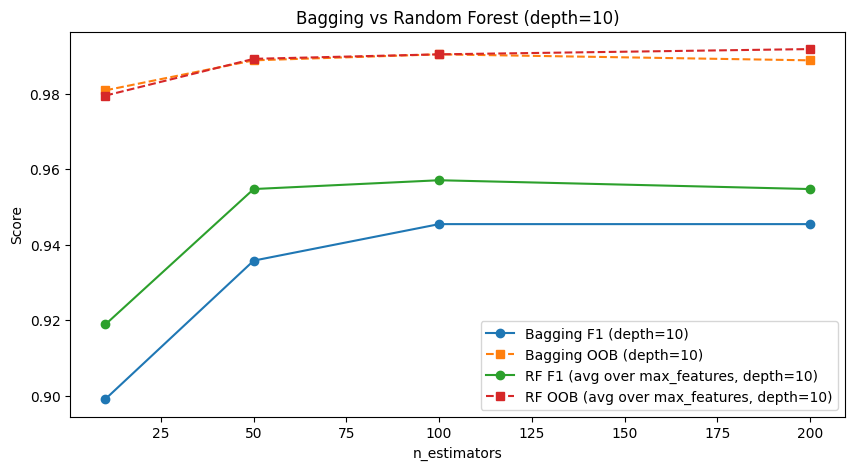

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import f1_score
from time import time

# === Load and preprocess ===
digits = load_digits()
X = StandardScaler().fit_transform(digits.data)
y = np.where(digits.target == 1, 1, -1)  # Binary: digit 1 vs others

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

# === Parameter grids ===
n_estimators_list = [10, 50, 100, 200]
max_depth_list = [None, 5, 10, 20]
max_features_list = [1.0, 0.7, 0.5, 0.3]

bagging_results = []
rf_results = []

# === BaggingClassifier (Decision Tree base) ===
for n in n_estimators_list:
    for depth in max_depth_list:
        t0 = time()
        base_tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
        model = BaggingClassifier(
            estimator=base_tree,
            n_estimators=n,
            oob_score=True,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)
        train_time = time() - t0
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred)
        bagging_results.append((n, depth, f1, train_time, model.oob_score_))

# === RandomForestClassifier ===
for n in n_estimators_list:
    for depth in max_depth_list:
        for mf in max_features_list:
            t0 = time()
            model = RandomForestClassifier(
                n_estimators=n,
                max_depth=depth,
                max_features=mf,
                oob_score=True,
                random_state=42,
                n_jobs=-1
            )
            model.fit(X_train, y_train)
            train_time = time() - t0
            y_pred = model.predict(X_test)
            f1 = f1_score(y_test, y_pred)
            rf_results.append((n, depth, mf, f1, train_time, model.oob_score_))

# === Convert to arrays for easier plotting ===
bagging_results = np.array(bagging_results, dtype=object)
rf_results = np.array(rf_results, dtype=object)

# === Plot 1: F1 vs n_estimators for different depths (Bagging) ===
plt.figure(figsize=(10, 5))
for depth in max_depth_list:
    mask = bagging_results[:, 1] == depth
    plt.plot(bagging_results[mask, 0], bagging_results[mask, 2],
             'o-', label=f'Depth={depth}')
plt.xlabel("n_estimators")
plt.ylabel("F1 Score")
plt.title("Bagging: F1 vs n_estimators for different max_depth")
plt.legend()
plt.show()

# === Plot 2: OOB vs n_estimators (Bagging) ===
plt.figure(figsize=(10, 5))
for depth in max_depth_list:
    mask = bagging_results[:, 1] == depth
    plt.plot(bagging_results[mask, 0], bagging_results[mask, 4],
             's--', label=f'Depth={depth}')
plt.xlabel("n_estimators")
plt.ylabel("OOB Score")
plt.title("Bagging: OOB vs n_estimators")
plt.legend()
plt.show()

# === Plot 3: Random Forest F1 vs n_estimators for different max_features ===
plt.figure(figsize=(10, 5))
for mf in max_features_list:
    mask = rf_results[:, 2] == mf
    plt.plot(rf_results[mask, 0], rf_results[mask, 3], 'o-', label=f"max_features={mf}")
plt.xlabel("n_estimators")
plt.ylabel("F1 Score")
plt.title("Random Forest: F1 vs n_estimators (various max_features)")
plt.legend()
plt.show()

# === Plot 4: Random Forest OOB vs n_estimators ===
plt.figure(figsize=(10, 5))
for mf in max_features_list:
    mask = rf_results[:, 2] == mf
    plt.plot(rf_results[mask, 0], rf_results[mask, 5], 's--', label=f"max_features={mf}")
plt.xlabel("n_estimators")
plt.ylabel("OOB Score")
plt.title("Random Forest: OOB vs n_estimators")
plt.legend()
plt.show()

# === Plot 5: Training time comparison (Bagging vs Random Forest) ===
plt.figure(figsize=(10, 5))
plt.plot(bagging_results[:, 0], bagging_results[:, 3], 'o-', label='Bagging')
for mf in max_features_list:
    mask = rf_results[:, 2] == mf
    plt.plot(rf_results[mask, 0], rf_results[mask, 4], '--', label=f'RF (mf={mf})')
plt.xlabel("n_estimators")
plt.ylabel("Training Time (s)")
plt.title("Training Time vs Model Size")
plt.legend()
plt.show()

# === Summary ===
print("\n===== BAGGING Summary =====")
for n, depth, f1, t, oob in bagging_results:
    print(f"n={n:3d}, depth={str(depth):>4}, F1={f1:.3f}, OOB={oob:.3f}, time={t:.2f}s")

print("\n===== RANDOM FOREST Summary =====")
for n, depth, mf, f1, t, oob in rf_results:
    print(f"n={n:3d}, depth={str(depth):>4}, mf={mf:.2f}, F1={f1:.3f}, OOB={oob:.3f}, time={t:.2f}s")
    
# ==== Comparision ======
# Filter by a representative depth (e.g., 10)
depth_ref = 10

# Average RF results across max_features for fair comparison
rf_avg = []
for n in np.unique(rf_results[:, 0]):
    mask = (rf_results[:, 0] == n) & (rf_results[:, 1] == depth_ref)
    if np.any(mask):
        f1_mean = np.mean(rf_results[mask, 3].astype(float))
        oob_mean = np.mean(rf_results[mask, 5].astype(float))
        rf_avg.append((n, f1_mean, oob_mean))
rf_avg = np.array(rf_avg)

# Get Bagging results for same depth
bag_mask = bagging_results[:, 1] == depth_ref
bag_f1 = bagging_results[bag_mask, 2].astype(float)
bag_oob = bagging_results[bag_mask, 4].astype(float)
bag_n = bagging_results[bag_mask, 0].astype(int)

# === Plot comparison ===
plt.figure(figsize=(10,5))
plt.plot(bag_n, bag_f1, 'o-', label=f'Bagging F1 (depth={depth_ref})')
plt.plot(bag_n, bag_oob, 's--', label=f'Bagging OOB (depth={depth_ref})')
plt.plot(rf_avg[:,0], rf_avg[:,1], 'o-', label=f'RF F1 (avg over max_features, depth={depth_ref})')
plt.plot(rf_avg[:,0], rf_avg[:,2], 's--', label=f'RF OOB (avg over max_features, depth={depth_ref})')
plt.xlabel("n_estimators")
plt.ylabel("Score")
plt.title("Bagging vs Random Forest (depth=10)")
plt.legend()
plt.show()


## B2- AdaBoost and XGBoost / Gradinet Boosting 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import make_scorer, f1_score
import xgboost as xgb
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

/usr/local/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [13:07:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [13:07:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [13:07:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [13:07:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr

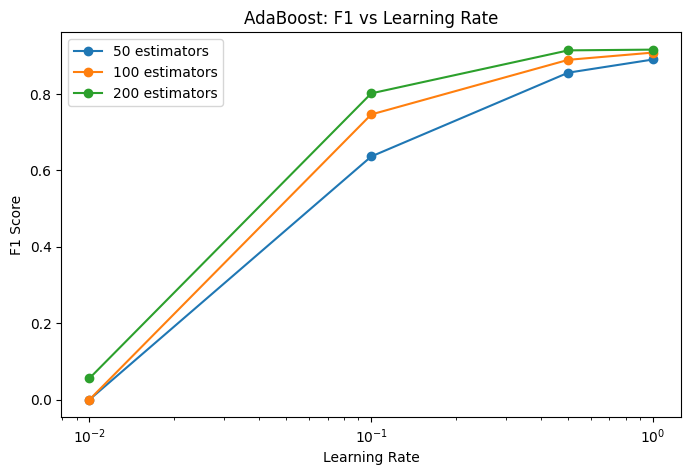

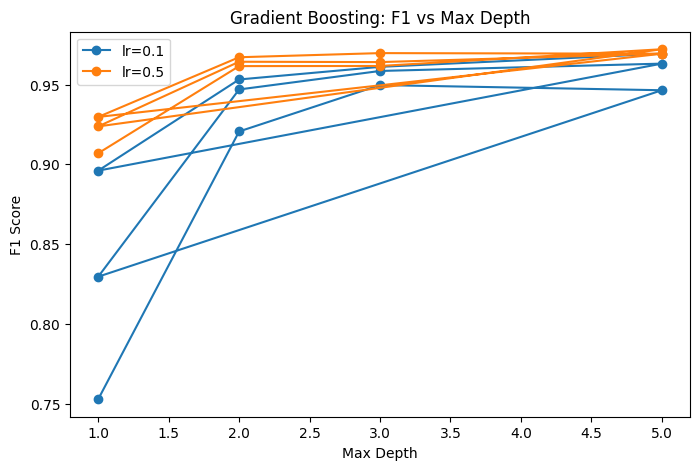

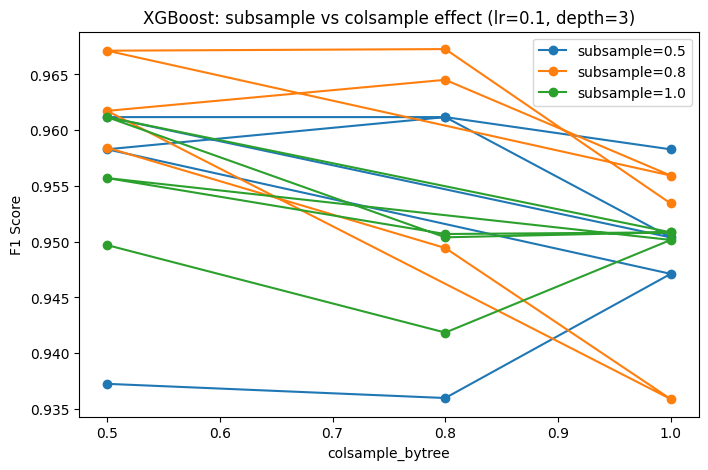


===== BEST MODELS =====
AdaBoost: lr=1.0, n_estimators=200, F1=0.916
GradientBoosting: lr=0.5, n_estimators=50, depth=5, F1=0.972
XGBoost: lr=0.5, n_estimators=50, depth=3, subsample=0.8, colsample=0.5, F1=0.969


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1 = make_scorer(f1_score)

# === Hyperparameter grids ===
n_estimators_list = [50, 100, 200]
learning_rates = [0.01, 0.1, 0.5, 1.0]
max_depths = [1, 2, 3, 5]
subsamples = [0.5, 0.8, 1.0]
colsamples = [0.5, 0.8, 1.0]

# Containers
results_ada, results_gb, results_xgb = [], [], []

# === AdaBoost (Decision Stumps) ===
for lr in learning_rates:
    for n in n_estimators_list:
        model = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1),
            n_estimators=n,
            learning_rate=lr,
            random_state=42
        )
        acc = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1).mean()
        f1s = cross_val_score(model, X, y, cv=cv, scoring=f1, n_jobs=-1).mean()
        results_ada.append((lr, n, acc, f1s))

# === Gradient Boosting ===
for lr in learning_rates:
    for n in n_estimators_list:
        for d in max_depths:
            model = GradientBoostingClassifier(
                n_estimators=n,
                learning_rate=lr,
                max_depth=d,
                random_state=42
            )
            acc = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1).mean()
            f1s = cross_val_score(model, X, y, cv=cv, scoring=f1, n_jobs=-1).mean()
            results_gb.append((lr, n, d, acc, f1s))


# === XGBoost ===
y_xgb = np.where(y == -1, 0, 1)  # Convert to {0,1} labels

for lr in learning_rates:
    for n in n_estimators_list:
        for d in max_depths:
            for ss in subsamples:
                for cs in colsamples:
                    model = xgb.XGBClassifier(
                        n_estimators=n,
                        learning_rate=lr,
                        max_depth=d,
                        subsample=ss,
                        colsample_bytree=cs,
                        eval_metric='logloss',
                        use_label_encoder=False,
                        n_jobs=-1,
                        random_state=42
                    )
                    acc = cross_val_score(model, X, y_xgb, cv=cv, scoring="accuracy", n_jobs=-1).mean()
                    f1s = cross_val_score(model, X, y_xgb, cv=cv, scoring=f1, n_jobs=-1).mean()
                    results_xgb.append((lr, n, d, ss, cs, acc, f1s))


# Convert to arrays
results_ada = np.array(results_ada, dtype=object)
results_gb = np.array(results_gb, dtype=object)
results_xgb = np.array(results_xgb, dtype=object)

# === Plot: AdaBoost learning rate vs performance ===
plt.figure(figsize=(8,5))
for n in n_estimators_list:
    mask = results_ada[:,1] == n
    plt.plot(results_ada[mask,0], results_ada[mask,3], 'o-', label=f'{n} estimators')
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("F1 Score")
plt.title("AdaBoost: F1 vs Learning Rate")
plt.legend()
plt.show()

# === Plot: Gradient Boosting F1 vs depth ===
plt.figure(figsize=(8,5))
for lr in [0.1, 0.5]:
    mask = results_gb[:,0] == lr
    plt.plot(results_gb[mask,2], results_gb[mask,4], 'o-', label=f'lr={lr}')
plt.xlabel("Max Depth")
plt.ylabel("F1 Score")
plt.title("Gradient Boosting: F1 vs Max Depth")
plt.legend()
plt.show()

# === Plot: XGBoost subsample and colsample effect ===
plt.figure(figsize=(8,5))
for ss in subsamples:
    mask = (results_xgb[:,0] == 0.1) & (results_xgb[:,3] == ss) & (results_xgb[:,2] == 3)
    plt.plot(results_xgb[mask,4], results_xgb[mask,6], 'o-', label=f'subsample={ss}')
plt.xlabel("colsample_bytree")
plt.ylabel("F1 Score")
plt.title("XGBoost: subsample vs colsample effect (lr=0.1, depth=3)")
plt.legend()
plt.show()

# === Summary ===
best_ada = results_ada[np.argmax(results_ada[:,3].astype(float))]
best_gb = results_gb[np.argmax(results_gb[:,4].astype(float))]
best_xgb = results_xgb[np.argmax(results_xgb[:,6].astype(float))]

print("\n===== BEST MODELS =====")
print(f"AdaBoost: lr={best_ada[0]}, n_estimators={best_ada[1]}, F1={best_ada[3]:.3f}")
print(f"GradientBoosting: lr={best_gb[0]}, n_estimators={best_gb[1]}, depth={best_gb[2]}, F1={best_gb[4]:.3f}")
print(f"XGBoost: lr={best_xgb[0]}, n_estimators={best_xgb[1]}, depth={best_xgb[2]}, subsample={best_xgb[3]}, colsample={best_xgb[4]}, F1={best_xgb[6]:.3f}")

## B3 - Stacking 


=== B3: Stacking ===
SVM          | Acc: 0.9766 ± 0.0072 | F1: 0.8838 ± 0.0383
RandomForest | Acc: 0.9950 ± 0.0037 | F1: 0.9748 ± 0.0190


/usr/local/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [13:13:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [13:13:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [13:13:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [13:13:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr

XGBoost      | Acc: 0.9933 ± 0.0057 | F1: 0.9673 ± 0.0286


[13:13:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.
[13:13:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.


[13:13:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[13:13:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[13:13:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[13:13:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[13:13:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[13:13:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" }

Stacking     | Acc: 0.9922 ± 0.0059 | F1: 0.9612 ± 0.0303


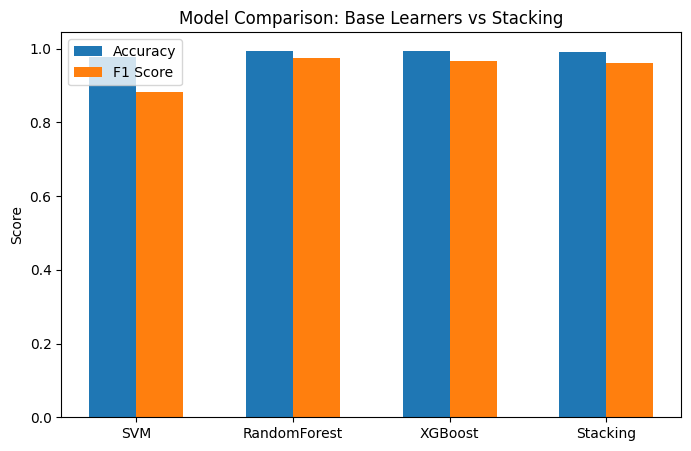


Best single model: RandomForest (F1=0.9748)
Stacking F1: 0.9612


In [7]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

# === Load and preprocess ===
digits = load_digits()
X = StandardScaler().fit_transform(digits.data)
y = np.where(digits.target == 1, 1, -1)
y_xgb = np.where(y == -1, 0, 1)  # for XGBoost

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1 = make_scorer(f1_score)

# === Base learners ===
base_learners = [
    ("svm", SVC(kernel='linear', probability=True, C=1.0, random_state=42)),
    ("rf", RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)),
    ("xgb", xgb.XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=3,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', use_label_encoder=False,
        n_jobs=-1, random_state=42))
]

# === Meta learner ===
meta_learner = LogisticRegression(max_iter=500, solver='lbfgs', random_state=42)

# === Stacking Classifier ===
stack = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,               # cross-validated stacking
    n_jobs=-1,
    passthrough=False   # only use meta-features (predictions)
)

# === Evaluate all models ===
print("\n=== B3: Stacking ===")

models = {
    "SVM": base_learners[0][1],
    "RandomForest": base_learners[1][1],
    "XGBoost": base_learners[2][1],
    "Stacking": stack
}

results_acc = {}
results_f1 = {}

for name, model in models.items():
    # For XGBoost use y_xgb instead of y
    target = y_xgb if name == "XGBoost" else y
    acc = cross_val_score(model, X, target, cv=cv, scoring="accuracy", n_jobs=-1)
    f1s = cross_val_score(model, X, target, cv=cv, scoring=f1, n_jobs=-1)
    results_acc[name] = (acc.mean(), acc.std())
    results_f1[name] = (f1s.mean(), f1s.std())
    print(f"{name:12s} | Acc: {acc.mean():.4f} ± {acc.std():.4f} | F1: {f1s.mean():.4f} ± {f1s.std():.4f}")

# === Compare visually ===
labels = list(results_acc.keys())
acc_means = [results_acc[m][0] for m in labels]
f1_means = [results_f1[m][0] for m in labels]

x = np.arange(len(labels))
plt.figure(figsize=(8,5))
plt.bar(x - 0.15, acc_means, width=0.3, label='Accuracy')
plt.bar(x + 0.15, f1_means, width=0.3, label='F1 Score')
plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Model Comparison: Base Learners vs Stacking")
plt.legend()
plt.show()

# === Identify best single model ===
best_single = max([m for m in models.keys() if m != "Stacking"],
                  key=lambda m: results_f1[m][0])
print(f"\nBest single model: {best_single} (F1={results_f1[best_single][0]:.4f})")
print(f"Stacking F1: {results_f1['Stacking'][0]:.4f}")


## Fair comparision

/usr/local/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [13:18:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [13:18:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [13:18:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [13:18:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr


=== B4: Fair Comparison ===
         Model  Accuracy Mean  Accuracy Std  F1 Mean   F1 Std
Best SVM (RBF)       0.996660      0.002085 0.983633 0.010277
 Random Forest       0.994994      0.003686 0.974794 0.019024
       XGBoost       0.993326      0.005721 0.967261 0.028613
      Stacking       0.992211      0.005936 0.961160 0.030308


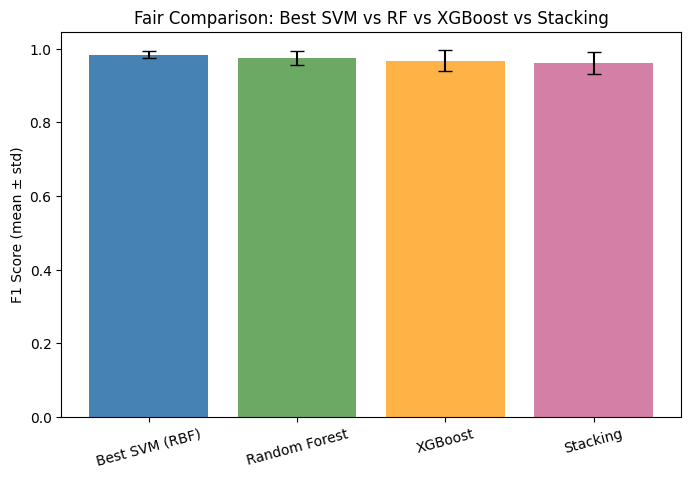

In [13]:

# Ensure same CV and scorer
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1 = make_scorer(f1_score)

# === Define the final 4 models for fair comparison ===
from sklearn.svm import SVC

models_final = {
    "Best SVM (RBF)": SVC(C=1.0, kernel='rbf', gamma=0.01, probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=3,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', use_label_encoder=False,
        n_jobs=-1, random_state=42),
    "Stacking": stack
}


# XGBoost requires 0/1 labels
y_xgb = np.where(y == -1, 0, 1)

# === Evaluate all models ===
results_fair = []
for name, model in models_final.items():
    target = y_xgb if name == "XGBoost" else y
    acc = cross_val_score(model, X, target, cv=cv, scoring="accuracy", n_jobs=-1)
    f1s = cross_val_score(model, X, target, cv=cv, scoring=f1, n_jobs=-1)
    results_fair.append({
        "Model": name,
        "Accuracy Mean": acc.mean(),
        "Accuracy Std": acc.std(),
        "F1 Mean": f1s.mean(),
        "F1 Std": f1s.std()
    })

# === Build and print concise comparison table ===
df_fair = pd.DataFrame(results_fair)
print("\n=== B4: Fair Comparison ===")
print(df_fair.to_string(index=False))

# Optional: plot for the report
plt.figure(figsize=(8,5))
plt.bar(df_fair["Model"], df_fair["F1 Mean"], yerr=df_fair["F1 Std"], capsize=5, color=["#4682b4","#6ca965","#ffb347","#d47fa6"])
plt.ylabel("F1 Score (mean ± std)")
plt.title("Fair Comparison: Best SVM vs RF vs XGBoost vs Stacking")
plt.xticks(rotation=15)
plt.show()


## Reflection

Working with support vector machines helped me to understand how margin and regularization parameter balance the trade-off between fitting the data closely and keeping the decision boundary simple. A large margin with strong regularization encourages a model that generalizes better, whereas the choice of kernel determines how flexible the decision function can get: A linear kernel constrains the model into linear patterns, whereas nonlinear kernels, such as the radial basis function, allow the classifier to capture more complicated structures.

Looking into the ensemble methods made it clear how they handle the bias-variance tradeoff. The bagging methods, like random forests, reduce the variance by averaging many diverse trees, while boosting methods gradually correct errors from previous learners and may reduce bias by building strong predictors from weaker ones. Actually seeing these approaches in behavior made this abstract idea of bias and variance more concrete.

Working with real data also highlighted common issues that come into play when considering machine learning in practice. This includes imputation of missing values, encoding of categorical features, and handling of class imbalance-all issues where careful attention must be paid to avoid training a model on incomplete information, misinterpreting categorical features, or making biased predictions due to skewed classes. The addressing of these challenges better placed me to understand what exactly it takes to migrate from clean academic examples to realistic applications.